In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("../data/cleaned/phishing_cleaned.csv")

df.head()

,URL,URLLength,Domain,DomainLength,IsDomainIP,TLD,URLSimilarityIndex,CharContinuationRate,TLDLegitimateProb,URLCharProb,...,Pay,Crypto,HasCopyrightInfo,NoOfImage,NoOfCSS,NoOfJS,NoOfSelfRef,NoOfEmptyRef,NoOfExternalRef,label
0,https://www.southbankmosaics.com,31,www.southbankmosaics.com,24,0,com,100.0,1.000000,0.522907,0.061933,...,0,0,1,34,20,28,119,0,124,0
1,https://www.uni-mainz.de,23,www.uni-mainz.de,16,0,de,100.0,0.666667,0.032650,0.050207,...,0,0,1,50,9,8,39,0,217,0
2,https://www.voicefmradio.co.uk,29,www.voicefmradio.co.uk,22,0,uk,100.0,0.866667,0.028555,0.064129,...,0,0,1,10,2,7,42,2,5,0
3,https://www.sfnmjournal.com,26,www.sfnmjournal.com,19,0,com,100.0,1.000000,0.522907,0.057606,...,1,1,1,3,27,15,22,1,31,0
4,https://www.rewildingargentina.org,33,www.rewildingargentina.org,26,0,org,100.0,1.000000,0.079963,0.059441,...,1,0,1,244,15,34,72,1,85,0


In [2]:
# Change columns names to make our charts more readable
df["website_type"] = df["label"].map({
    0: "Legitimate",
    1: "Phishing"
})

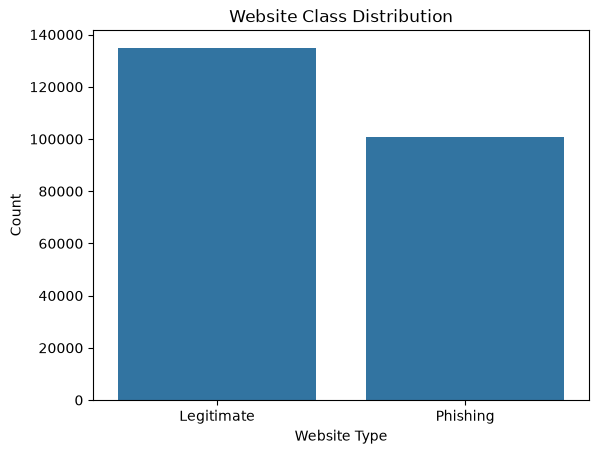

In [ ]:
# Distribution of website_type
sns.countplot(data=df, x="website_type")

plt.title("Website Class Distribution")
plt.xlabel("Website Type")
plt.ylabel("Count")

plt.show()

### Key Finding
- Legitimate websites account for approximately more than 50% of the dataset, while phishing websites account for XX%.
- The dataset is reasonably balanced, although legitimate websites represent the larger class.
- Because the imbalance is not extreme, accuracy can still be useful, but precision, recall, F1-score, and ROC-AUC will also be considered during modeling.

In [ ]:

numeric_features = [
    "URLLength",
    "DomainLength",
    "LineOfCode",
    "NoOfURLRedirect",
    "NoOfPopup",
    "NoOfiFrame",
    "NoOfExternalRef"
]
# Mean of numeric features for both types of websites
df.groupby("website_type")[numeric_features].mean().T

website_type,Legitimate,Phishing
URLLength,26.228610,45.720293
DomainLength,19.228610,24.465144
LineOfCode,1947.491680,65.730467
NoOfURLRedirect,0.119770,0.151696
NoOfPopup,0.380467,0.009758
NoOfiFrame,2.714535,0.084581
NoOfExternalRef,85.294601,1.128119


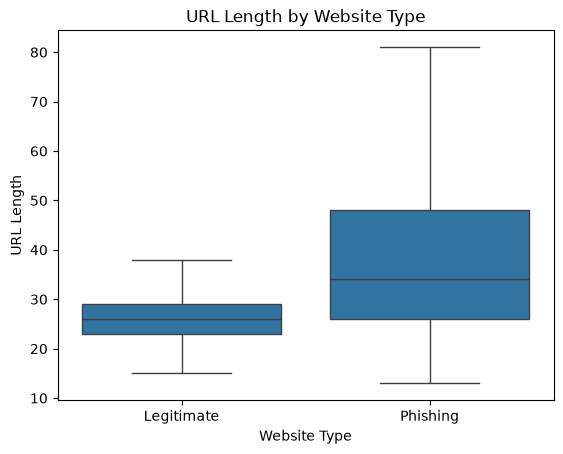

In [ ]:
# Compare URL length between legitimate and phishing websites
sns.boxplot(
    data=df,
    x="website_type",
    y="URLLength",
    showfliers=False
)

plt.title("URL Length by Website Type")
plt.xlabel("Website Type")
plt.ylabel("URL Length")

plt.show()

### Key Finding
- Phishing websites have noticeably longer URLs
- The phishing group also shows much greater variation in URL length.
- This suggests URL length may be a useful feature for distinguishing phishing websites.

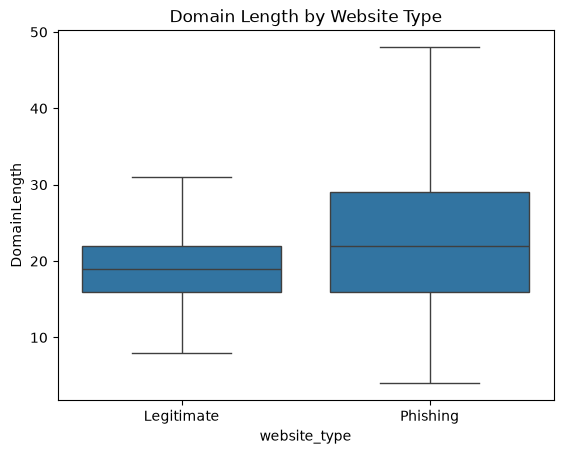

In [ ]:
# Compare domain length between the two website classes
sns.boxplot(
    data=df,
    x="website_type",
    y="DomainLength",
    showfliers=False
)

plt.title("Domain Length by Website Type")

plt.show()

### Key Finding
- Phishing websites have longer domains on average than legitmate websites
- Domain lengths also vary more among phishing websites, suggesting domain length may provide useful classification information.

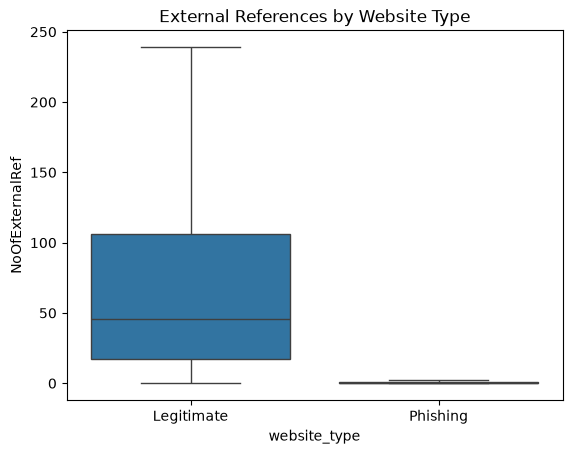

In [ ]:

# Compare the number of external references
sns.boxplot(
    data=df,
    x="website_type",
    y="NoOfExternalRef",
    showfliers=False
)

plt.title("External References by Website Type")

plt.show()

### Key Finding
- Legitimate websites contain far more external references than phishing
- This is one of the clearest structural differences between the two classes and may be a strong indicator of legitimacy.

In [10]:
# Select interpretable binary website characteristics
binary_features = [
    "IsHTTPS",
    "IsDomainIP",
    "HasPasswordField",
    "HasHiddenFields",
    "HasExternalFormSubmit",
    "HasSocialNet",
    "HasCopyrightInfo",
    "Bank",
    "Pay",
    "Crypto"
]

# Calculate phishing rate when each feature is present
phishing_rates = []

for feature in binary_features:
    
    # Because phishing = 1, the mean of label gives the phishing proportion
    rate = df.loc[df[feature] == 1, "label"].mean() * 100
    
    phishing_rates.append({
        "Feature": feature,
        "Phishing Rate": rate
    })

# Convert results into a DataFrame
phishing_rates_df = pd.DataFrame(phishing_rates)

# Rank characteristics from highest to lowest phishing rate
phishing_rates_df = phishing_rates_df.sort_values(
    "Phishing Rate",
    ascending=False
)

phishing_rates_df

,Feature,Phishing Rate
1,IsDomainIP,100.000000
0,IsHTTPS,26.926016
2,HasPasswordField,22.552150
7,Bank,18.306804
9,Crypto,11.020777
8,Pay,10.872327
3,HasHiddenFields,10.569918
6,HasCopyrightInfo,5.042734
4,HasExternalFormSubmit,4.155418
5,HasSocialNet,0.474656


### Key Findings
- Websites using an **IP address as the domain had a 100% phishing rate** in this dataset, making it the strongest risk indicator in this comparison.
- HTTPS and password-field websites had phishing rates of about **27% and 23%**, showing that these features alone do not indicate legitimacy or phishing.
- Social network links and copyright information were associated with particularly low phishing rates.

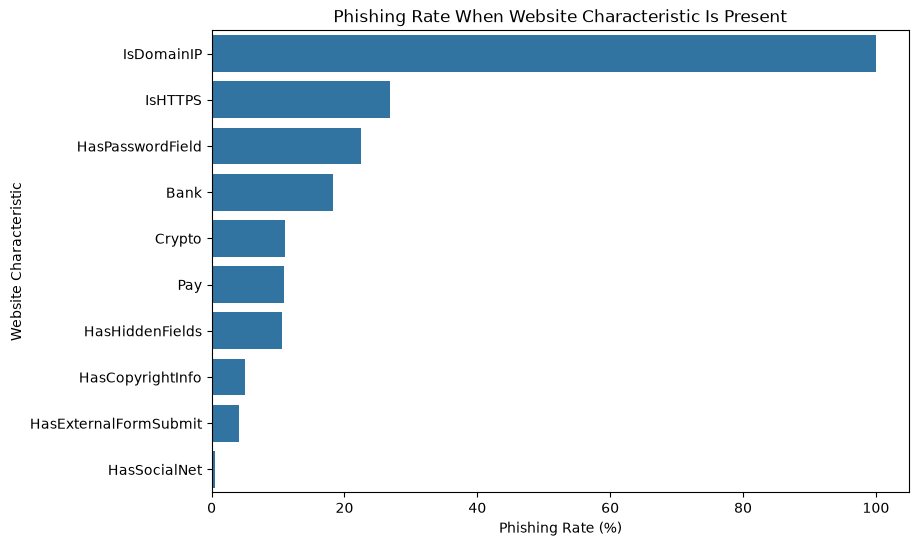

In [11]:
# Visualize phishing rates when each characteristic is present
plt.figure(figsize=(9, 6))

sns.barplot(
    data=phishing_rates_df,
    x="Phishing Rate",
    y="Feature"
)

plt.title("Phishing Rate When Website Characteristic Is Present")
plt.xlabel("Phishing Rate (%)")
plt.ylabel("Website Characteristic")

plt.show()

In [12]:
# Keep only numeric columns for correlation analysis
numeric_df = df.select_dtypes(include="number")

# Calculate each feature's correlation with the phishing target
target_corr = (
    numeric_df.corr()["label"]
    .drop("label")
    .sort_values()
)

target_corr

URLSimilarityIndex           -0.860358
HasSocialNet                 -0.784255
HasCopyrightInfo             -0.743358
HasDescription               -0.690232
IsHTTPS                      -0.609132
DomainTitleMatchScore        -0.584905
HasSubmitButton              -0.578561
IsResponsive                 -0.548608
URLTitleMatchScore           -0.539419
HasHiddenFields              -0.507731
HasFavicon                   -0.493711
URLCharProb                  -0.469749
CharContinuationRate         -0.467735
HasTitle                     -0.459725
Robots                       -0.392620
NoOfJS                       -0.373500
Pay                          -0.359747
NoOfSelfRef                  -0.316211
NoOfImage                    -0.274658
LineOfCode                   -0.272257
NoOfExternalRef              -0.258627
NoOfiFrame                   -0.225822
Bank                         -0.188959
HasExternalFormSubmit        -0.167574
HasPasswordField             -0.138183
NoOfEmptyRef             

In [13]:
# Identify the first 15 features with the strongest absolute
top_features = (
    target_corr.abs()
    .sort_values(ascending=False)
    .head(15)
    .index
)

# Keep the original signed correlations so direction is preserved
strongest_corr = target_corr.loc[top_features].sort_values()

strongest_corr

URLSimilarityIndex      -0.860358
HasSocialNet            -0.784255
HasCopyrightInfo        -0.743358
HasDescription          -0.690232
IsHTTPS                 -0.609132
DomainTitleMatchScore   -0.584905
HasSubmitButton         -0.578561
IsResponsive            -0.548608
URLTitleMatchScore      -0.539419
HasHiddenFields         -0.507731
HasFavicon              -0.493711
URLCharProb             -0.469749
CharContinuationRate    -0.467735
HasTitle                -0.459725
SpacialCharRatioInURL    0.533537
Name: label, dtype: float64

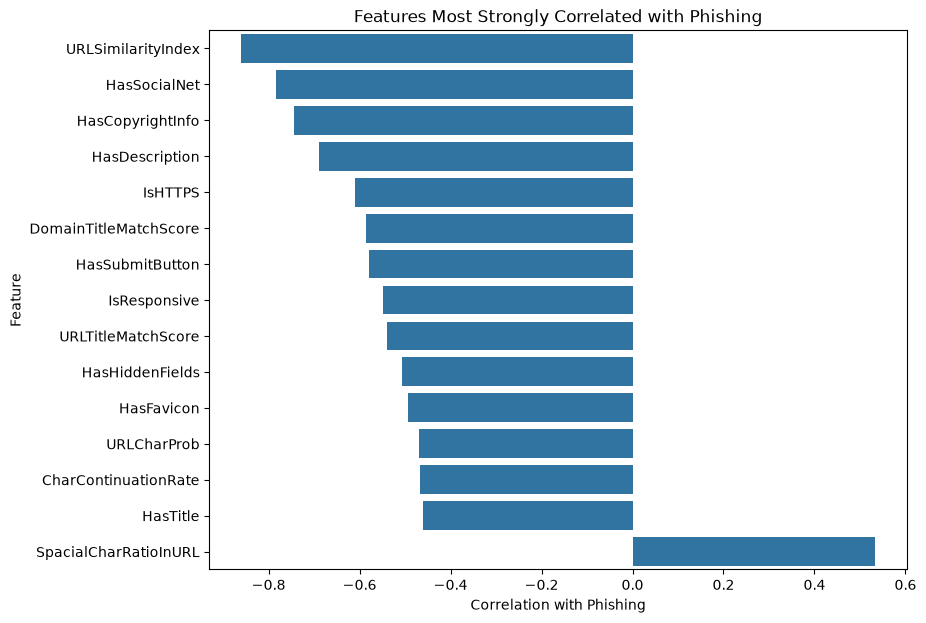

In [ ]:
# Visualize the strongest correlations with phishing
plt.figure(figsize=(9, 7))

sns.barplot(
    x=strongest_corr.values,
    y=strongest_corr.index
)

plt.title("Features Most Strongly Correlated with Phishing")
plt.xlabel("Correlation with Phishing")
plt.ylabel("Feature")

plt.show()

### Key Findings
- `URLSimilarityIndex` has the strongest relationship with the target (**-0.86**), followed by `HasSocialNet` (**-0.78**) and `HasCopyrightInfo` (**-0.74**).
- Several legitimacy-related features, including HTTPS, descriptions, social links, and copyright information, are negatively associated with phishing.
- `SpacialCharRatioInURL` stands out in the opposite direction (**+0.54**), meaning higher special-character ratios are associated with phishing websites.
- These strong relationships suggest several features could be valuable predictors in the ML models.

In [20]:
# Select the strongest target-related features identified above
top_feature_names = strongest_corr.index.tolist()

# Calculate correlations between these predictors
predictor_corr = df[top_feature_names].corr()



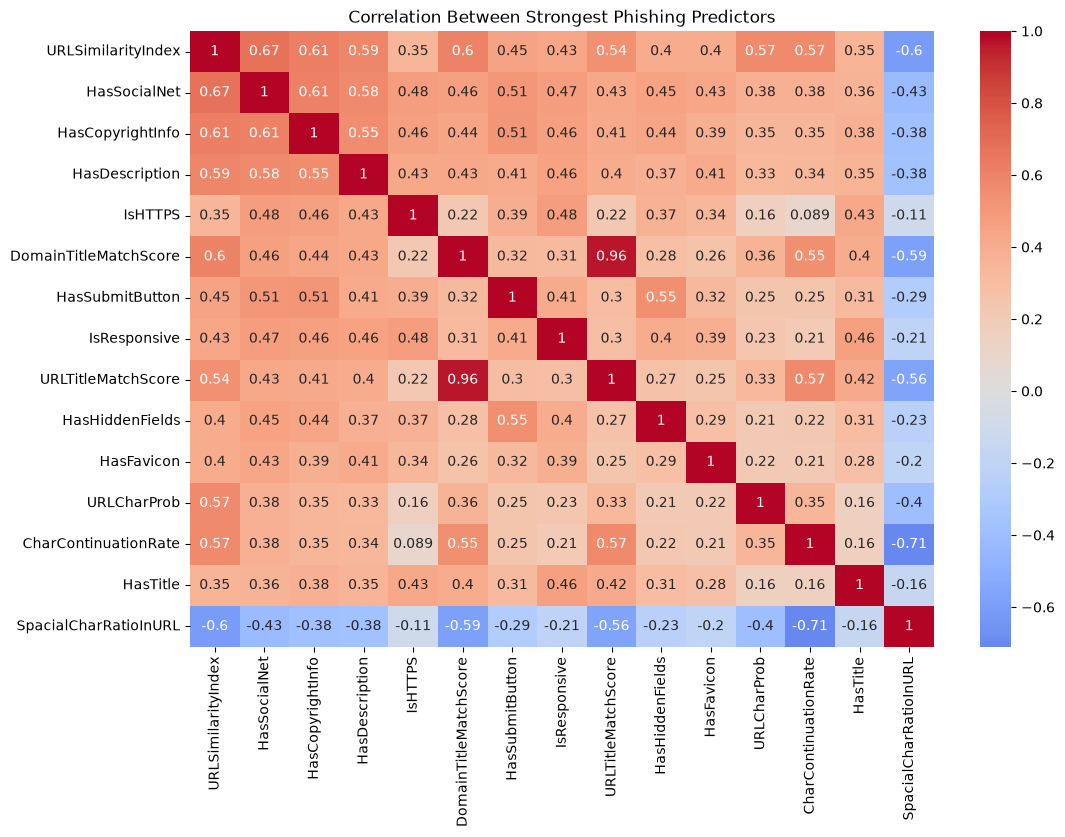

In [21]:
# Visualize relationships between the strongest predictors
plt.figure(figsize=(12, 8))

sns.heatmap(
    predictor_corr,
    cmap="coolwarm",
    center=0,
    annot=True
    
)

plt.title("Correlation Between Strongest Phishing Predictors")

plt.show()

### Key Findings
- `DomainTitleMatchScore` and `URLTitleMatchScore` are extremely highly correlated (**0.96**), suggesting they contain very similar information.
- `CharContinuationRate` and `SpacialCharRatioInURL` also have a strong inverse relationship (**-0.71**).
- Several other predictors show moderate correlations, but most are not extreme.
- These relationships are important to consider for selecting features for our reduced-feature ML model.